# Prueba del Machine Learning - microservicioMLL

Este notebook es una **replica ejecutable y autocontenida** del pipeline de ML real del
microservicio (`scripts/generar_dataset.py`, `scripts/train_models.py`,
`app/services/rules.py`, `app/services/anomaly_detector.py`, `app/services/predictor.py`,
`app/api/routes/inference.py`).

No importa esos modulos directamente (este notebook corre fuera del proyecto), pero **copia
la misma logica linea por linea** para que el comportamiento sea identico al servicio real.

El notebook esta dividido en partes **completamente separadas**, para que quede claro que son
dos tipos de aprendizaje distintos y no una sola mezcla:

- **PARTE 0**: fundamentos compartidos - de donde salen los datos, como se limpian y como se
  valida que esten bien (esto no es "modelo", es la materia prima que usan ambas partes).
- **PARTE A - APRENDIZAJE NO SUPERVISADO**: un unico modelo, `IsolationForest`, entrenado
  **sin ninguna etiqueta**, para deteccion de anomalias/outliers.
- **PARTE B - APRENDIZAJE SUPERVISADO**: los 3 modelos `RandomForest` (2 clasificadores + 1
  regresor), cada uno entrenado **comparando contra una respuesta ya conocida**, entrenados
  **en paralelo** entre si con `ThreadPoolExecutor`.
- **PARTE C**: el ensamble de produccion (reglas + Parte A + Parte B) probado **a traves de la
  API real** (un endpoint FastAPI identico al del servicio, llamado con `TestClient`, no solo
  con funciones de Python sueltas).
- **PARTE D**: comparacion final supervisado vs. no supervisado y conclusiones.


## PARTE 0 - Fundamentos compartidos

### 0.1 Esquema de datos del sistema (Neon/PostgreSQL)

El microservicio no genera los datos que consume: los lee de tablas que ya existen en la base de
datos compartida con el Servicio Gestor y la app movil. A partir de los `import` y consultas SQLAlchemy
en `app/api/routes/*.py` y `app/services/*.py`, estas son las tablas relevantes para el ML:

| Tabla | Columnas usadas por el MLL | Rol en el pipeline |
|---|---|---|
| `lotes_cafe` | `id_lote`, `id_usuario`, `id_sensor`, `tipo_proceso`, `fecha_inicio_secado`, `nombre_lote`, `codigo_qr` | Da contexto: que proceso (lavado/honey/natural) y desde cuando se seca el lote |
| `lecturas_ambientales` | `id_lectura`, `id_sensor`, `id_lote`, `temperatura`, `humedad`, `humedad_grano`, `temperatura_grano`, `luz`, `lluvia`, `timestamp` | Lecturas crudas de los 5 sensores IoT; es la fuente de los **features** |
| `alertas` | `id_alerta`, `id_lote`, `id_sensor`, `tipo_alerta`, `mensaje`, `nivel_severidad`, `atendida`, `fecha_generada` | Salida: anomalias de severidad riesgo/critico detectadas por el modelo |
| `predicciones` | `id_prediccion`, `id_lote`, `id_modelo`, `tiempo_estimado_horas`, `calidad_estimada`, `confianza`, `fecha_prediccion` | Salida: predicciones de tiempo restante y calidad |
| `recomendaciones` | `id_recomendacion`, `id_lote`, `texto`, `origen`, `fecha_generada` | Salida: texto accionable para el productor |
| `retroalimentacion_ml` | `id_retroalimentacion`, `id_lote`, `tipo_proceso`, `temperatura_grano`, `temperatura_ambiental`, `humedad_ambiental`, `humedad_grano`, `lluvia`, `luz`, `tiempo_real_horas`, `calidad_real` | Etiquetas **reales** reportadas por el productor (RNF-19), para reentrenar |
| `modelos_ml` | `id_modelo`, `nombre`, `version`, `tipo`, `activo`, `fecha_entrenamiento` | Registro/versionado de que modelo genero cada prediccion |

### 0.2 Estructura del dataset de entrenamiento

`scripts/generar_dataset.py` simula lotes completos de secado y, con las reglas de dominio, calcula
las etiquetas. El dataset resultante (`data/raw/lecturas_ml_training.csv`) tiene esta estructura:

| Columna | Tipo | Origen / sensor | Descripcion |
|---|---|---|---|
| `id_lote` | int | - | Identificador del lote simulado |
| `tipo_proceso` | categorica | - | `lavado` / `honey` / `natural` |
| `horas_transcurridas` | float | - | Horas desde que inicio el secado (feature temporal) |
| `horas_restantes` | float | - | **Etiqueta** del modelo de regresion de tiempo (Parte B) |
| `temperatura_grano` | float | DS18B20 | Feature numerica |
| `temperatura_ambiental` | float | BME280 | Feature numerica |
| `humedad_ambiental` | float | BME280 | Feature numerica |
| `humedad_grano` | float | Sensor capacitivo | Feature numerica |
| `lluvia` | float (0-1) | FC-37 | Feature numerica |
| `luz` | float (lux) | BH1750 | Feature numerica |
| `_es_anomalia` | bool | Regla de dominio | Usada solo para calibrar contamination en Parte A, NUNCA para entrenar |
| `_severidad` | categorica | Regla de dominio | normal / advertencia / riesgo / critico |
| `_tipo_anomalia` | categorica | Regla de dominio | **Etiqueta** del clasificador de tipo de anomalia (Parte B) |
| `_calidad_final_lote` | categorica | Score de riesgo acumulado por lote | **Etiqueta** del clasificador de calidad (Parte B) |

Ademas, en el momento de entrenar (`scripts/train_models.py`) se agrega la columna derivada
`delta_temp = temperatura_grano - temperatura_ambiental`, que tambien es un feature.

A continuacion se reconstruye esta estructura paso a paso: reglas de dominio -> generacion ->
limpieza -> validacion. Recien despues de esto el notebook se separa en Parte A y Parte B.

In [1]:
%matplotlib inline
import math
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from concurrent.futures import ThreadPoolExecutor

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", None)

RNG = np.random.default_rng(42)
print("Librerias cargadas correctamente.")

# Nota sobre rendimiento: si el notebook tarda mucho (varios minutos) en vez de segundos,
# la causa mas comun en Windows es "n_jobs=-1" en RandomForest: sklearn intenta abrir
# procesos nuevos (backend "loky") y eso puede ser muy lento o colgarse dentro de Jupyter
# en Windows. Por eso las celdas de entrenamiento de este notebook usan n_jobs=1. Ademas,
# cada celda "pesada" imprime cuanto tardo, para saber exactamente cual es la lenta si
# algo sigue tomando demasiado tiempo.

Librerias cargadas correctamente.


### 0.3 Motor de reglas de dominio (`app/services/rules.py`)

Antes de entrenar cualquier modelo, el proyecto define un motor de reglas **determinista**
(umbrales fijos validados contra estandares SCA/CQI). Este motor es la fuente de las etiquetas
del dataset sintetico y tambien corre en produccion junto al ML (el ensamble). Se copia tal cual
para que las etiquetas de este notebook sean identicas a las de produccion.

In [2]:
SEVERITY_ORDER = ["normal", "advertencia", "riesgo", "critico"]

def _rank(sev):
    return SEVERITY_ORDER.index(sev) if sev in SEVERITY_ORDER else 0

def peor_severidad(*severidades):
    return SEVERITY_ORDER[max(_rank(s) for s in severidades)] if severidades else "normal"

# --- Umbrales Cuadro 9 (Documento de Calidad del Cafe y Reglas del Dominio) ---
TEMP_GRANO_BANDAS = {
    "lavado": [(35, "normal"), (38, "advertencia"), (40, "riesgo"), (float("inf"), "critico")],
    "honey": [(35, "normal"), (38, "advertencia"), (40, "riesgo"), (float("inf"), "critico")],
    "natural": [(38, "normal"), (42, "advertencia"), (45, "riesgo"), (float("inf"), "critico")],
}
HUMEDAD_AMBIENTAL_BANDAS = [(65, "normal"), (80, "advertencia"), (90, "riesgo"), (float("inf"), "critico")]
HUMEDAD_GRANO_MIN_SANO = 10.0
HUMEDAD_GRANO_MAX_ALMACEN = 12.5
LUZ_INSUFICIENTE_LUX = 5000
LLUVIA_UMBRAL = 0.30
FLUCTUACION_DELTA_C = 10.0
ESTANCAMIENTO_HORAS = 24
ESTANCAMIENTO_DELTA_MIN = 1.0

def _banda(valor, bandas):
    for limite, etiqueta in bandas:
        if valor <= limite:
            return etiqueta
    return bandas[-1][1]

def clasificar_temperatura_grano(tipo_proceso, temp_grano):
    bandas = TEMP_GRANO_BANDAS.get(tipo_proceso, TEMP_GRANO_BANDAS["lavado"])
    return _banda(temp_grano, bandas)

def clasificar_humedad_ambiental(humedad_ambiental):
    return _banda(humedad_ambiental, HUMEDAD_AMBIENTAL_BANDAS)

def clasificar_lluvia(lluvia):
    detectada = lluvia is not None and lluvia >= LLUVIA_UMBRAL
    return ("critico" if detectada else "normal"), detectada

def clasificar_fluctuacion(delta_temp_abs):
    if delta_temp_abs is not None and delta_temp_abs >= FLUCTUACION_DELTA_C:
        return "advertencia"
    return "normal"

def clasificar_secado_estancado(delta_humedad_grano_24h, humedad_grano):
    if humedad_grano is None or humedad_grano <= HUMEDAD_GRANO_MIN_SANO:
        return "normal"
    if delta_humedad_grano_24h is None:
        return "normal"
    if delta_humedad_grano_24h < ESTANCAMIENTO_DELTA_MIN and humedad_grano > HUMEDAD_GRANO_MAX_ALMACEN:
        return "riesgo"
    return "normal"

def clasificar_riesgo_moho(humedad_ambiental, temp_grano):
    if humedad_ambiental is not None and humedad_ambiental > 80 and temp_grano is not None and temp_grano > 25:
        return "riesgo"
    return "normal"

def clasificar_valor_imposible(temp_grano, humedad_ambiental, humedad_grano):
    if temp_grano is not None and (temp_grano < 0 or temp_grano > 85):
        return True
    if humedad_ambiental is not None and (humedad_ambiental < 0 or humedad_ambiental > 100):
        return True
    if humedad_grano is not None and (humedad_grano < 0 or humedad_grano > 100):
        return True
    return False

def evaluar_lectura(tipo_proceso, features, delta_temp_reciente=None, delta_humedad_grano_24h=None):
    tipo_proceso = (tipo_proceso or "lavado").lower()
    alertas = []
    if clasificar_valor_imposible(features.get("temperatura_grano"), features.get("humedad_ambiental"), features.get("humedad_grano")):
        alertas.append({"tipo": "valor_imposible", "severidad": "critico",
                         "mensaje": "Lectura de sensor fuera de rango fisico posible; revisar sensor/conexion.",
                         "variable": "sensor"})
    sev_temp = clasificar_temperatura_grano(tipo_proceso, features.get("temperatura_grano", 0.0))
    if sev_temp != "normal":
        alertas.append({"tipo": "temperatura_alta", "severidad": sev_temp,
                         "mensaje": "Temperatura del grano por encima del rango ideal para este proceso.",
                         "variable": "temperatura_grano"})
    sev_hr = clasificar_humedad_ambiental(features.get("humedad_ambiental", 0.0))
    if sev_hr != "normal":
        alertas.append({"tipo": "humedad_ambiental_alta", "severidad": sev_hr,
                         "mensaje": "Humedad ambiental elevada; riesgo de reabsorcion y moho.",
                         "variable": "humedad_ambiental"})
    sev_lluvia, lluvia_detectada = clasificar_lluvia(features.get("lluvia", 0.0))
    if lluvia_detectada:
        alertas.append({"tipo": "lluvia_detectada", "severidad": sev_lluvia,
                         "mensaje": "Lluvia detectada sobre el lote en secado.",
                         "variable": "lluvia"})
    sev_fluct = clasificar_fluctuacion(delta_temp_reciente)
    if sev_fluct != "normal":
        alertas.append({"tipo": "fluctuacion_termica", "severidad": sev_fluct,
                         "mensaje": "Cambio brusco de temperatura entre lecturas recientes.",
                         "variable": "temperatura_grano"})
    sev_estancado = clasificar_secado_estancado(delta_humedad_grano_24h, features.get("humedad_grano"))
    if sev_estancado != "normal":
        alertas.append({"tipo": "secado_estancado", "severidad": sev_estancado,
                         "mensaje": "La humedad del grano no ha bajado en las ultimas 24h.",
                         "variable": "humedad_grano"})
    sev_moho = clasificar_riesgo_moho(features.get("humedad_ambiental"), features.get("temperatura_grano"))
    if sev_moho != "normal" and sev_hr == "normal":
        alertas.append({"tipo": "riesgo_moho", "severidad": sev_moho,
                         "mensaje": "Combinacion de humedad y temperatura favorable a formacion de moho.",
                         "variable": "humedad_ambiental"})
    if features.get("luz") is not None and features.get("luz") < LUZ_INSUFICIENTE_LUX and sev_estancado != "normal":
        alertas.append({"tipo": "radiacion_insuficiente", "severidad": "advertencia",
                         "mensaje": "Poca luz solar sostenida mientras el secado esta estancado.",
                         "variable": "luz"})
    severidad_final = peor_severidad(*(a["severidad"] for a in alertas)) if alertas else "normal"
    variables = sorted({a["variable"] for a in alertas})
    tipo_principal = alertas[0]["tipo"] if alertas else "normal"
    if alertas:
        alertas.sort(key=lambda a: _rank(a["severidad"]), reverse=True)
        tipo_principal = alertas[0]["tipo"]
    return {"severidad": severidad_final, "es_anomalia": severidad_final != "normal",
            "alertas": alertas, "tipo_principal": tipo_principal, "variables_contribuyentes": variables}

RECOMENDACIONES = {
    "temperatura_alta": "Mueve el lote a sombra parcial o reduce su exposicion directa al sol hasta que la temperatura del grano baje al rango ideal.",
    "humedad_ambiental_alta": "Voltea el cafe con mayor frecuencia y mejora la ventilacion de la zona de secado para evitar reabsorcion de humedad.",
    "riesgo_moho": "Aumenta la frecuencia de volteo y ventilacion: la combinacion de humedad y temperatura actual favorece la formacion de moho.",
    "lluvia_detectada": "Prioridad maxima: cubre el lote con plastico o lona de inmediato para protegerlo de la lluvia.",
    "secado_estancado": "Revisa que el grosor de la capa este entre 2 y 10 cm y aumenta la frecuencia de volteo; la humedad del grano no esta bajando.",
    "fluctuacion_termica": "Se detecto un cambio brusco de temperatura ('montana rusa climatica'); aumenta la frecuencia de monitoreo preventivo.",
    "radiacion_insuficiente": "Poca luz solar sostenida con secado estancado: considera mover el lote a una zona con mas exposicion solar o usar secado asistido.",
    "valor_imposible": "Revisa la conexion y calibracion del sensor; la ultima lectura esta fuera de rango fisico posible.",
    "normal": "El lote se encuentra dentro de los parametros esperados para su tipo de proceso.",
}

def recomendacion_para(tipo_alerta):
    return RECOMENDACIONES.get(tipo_alerta, RECOMENDACIONES["normal"])

TIPO_SEVERIDAD_DEFAULT = {
    "normal": "normal", "temperatura_alta": "riesgo", "humedad_ambiental_alta": "riesgo",
    "riesgo_moho": "riesgo", "lluvia_detectada": "critico", "secado_estancado": "riesgo",
    "fluctuacion_termica": "advertencia", "radiacion_insuficiente": "advertencia", "valor_imposible": "critico",
}

DURACION_HORAS = {"lavado": (6 * 24, 9 * 24), "honey": (8 * 24, 23 * 24), "natural": (10 * 24, 28 * 24)}

print("Motor de reglas cargado:", len(TIPO_SEVERIDAD_DEFAULT), "tipos de anomalia definidos.")

Motor de reglas cargado: 9 tipos de anomalia definidos.


### 0.4 Recoleccion de datos: simulacion de lotes (`scripts/generar_dataset.py`)

Se simulan lotes completos de secado (no lecturas sueltas) para los 3 tipos de proceso, con 5
sensores fisicos y sus fallos ocasionales. En produccion estas lecturas vendrian de
`lecturas_ambientales`; aqui se generan sinteticamente para poder entrenar sin depender de la BD.

In [3]:
PROCESOS = ["lavado", "honey", "natural"]
LOTES_POR_PROCESO = 24
PASO_HORAS = 2
TEMP_IDEAL_MEDIO = {"lavado": 27.0, "honey": 28.0, "natural": 30.0}
PROB_FALLO_SENSOR = 0.02
FRAC_ANOMALIA_OBJETIVO = 0.10

def simular_lote(id_lote, tipo_proceso, rng):
    lo, hi = DURACION_HORAS[tipo_proceso]
    total_horas = int(rng.uniform(lo, hi))
    descuido = rng.beta(2, 5)
    humedad_grano_inicial = rng.uniform(45, 57)
    humedad_grano_final = rng.uniform(10, 12)
    temp_medio = TEMP_IDEAL_MEDIO[tipo_proceso] + descuido * rng.uniform(2, 8)
    cloud_factor_lote = rng.uniform(0.6, 1.0)
    filas = []
    humedad_grano_prev = humedad_grano_inicial
    temp_grano_prev = temp_medio
    racha_lluvia_restante = 0
    racha_lluvia_intensidad = 0.0
    for t in range(0, total_horas + 1, PASO_HORAS):
        hora_dia = t % 24
        progreso = t / max(total_horas, 1)
        luz_dia = max(0.0, math.sin(math.pi * (hora_dia - 6) / 12))
        pico_luz = rng.uniform(60000, 100000) * cloud_factor_lote
        luz = max(0.0, luz_dia * pico_luz + rng.normal(0, 1500))
        if racha_lluvia_restante > 0:
            lluvia = max(0.0, min(1.0, racha_lluvia_intensidad + rng.normal(0, 0.05)))
            racha_lluvia_restante -= 1
        else:
            prob_lluvia = 0.008 + 0.006 * descuido
            if rng.uniform() < prob_lluvia:
                racha_lluvia_restante = int(rng.integers(1, 4))
                racha_lluvia_intensidad = rng.uniform(0.3, 1.0)
                lluvia = racha_lluvia_intensidad
            else:
                lluvia = 0.0
        amplitud_temp = rng.uniform(4, 7)
        temperatura_ambiental = (temp_medio - 3 + amplitud_temp * math.sin(math.pi * (hora_dia - 8) / 12) + rng.normal(0, 0.8))
        if lluvia > 0:
            temperatura_ambiental -= rng.uniform(2, 5)
        humedad_ambiental = 48 - 0.9 * (temperatura_ambiental - temp_medio) + rng.normal(0, 3)
        humedad_ambiental += descuido * 6
        if lluvia > 0:
            humedad_ambiental += 25 + lluvia * 10
        humedad_ambiental = float(np.clip(humedad_ambiental, 15, 99))
        sobreexposicion = max(0.0, (luz / 100000) - 0.4) * (5 + descuido * 6)
        temperatura_grano = temperatura_ambiental + 2 + sobreexposicion + rng.normal(0, 0.6)
        avance_ideal = humedad_grano_inicial - (humedad_grano_inicial - humedad_grano_final) * min(progreso * 1.05, 1.0)
        factor_estancamiento = 1.0
        if humedad_ambiental > 80 or lluvia > 0:
            factor_estancamiento = rng.uniform(0.1, 0.5)
        humedad_grano = humedad_grano_prev - (humedad_grano_prev - avance_ideal) * 0.15 * factor_estancamiento
        humedad_grano = float(np.clip(humedad_grano + rng.normal(0, 0.3), humedad_grano_final - 1, 100))
        valor_imposible = rng.uniform() < 0.004
        if valor_imposible:
            if rng.uniform() < 0.5:
                temperatura_grano = rng.uniform(90, 120)
            else:
                humedad_ambiental = rng.uniform(-5, 3)
        lectura_estancada = rng.uniform() < 0.006
        if lectura_estancada and filas:
            temperatura_grano = temp_grano_prev
            humedad_grano = humedad_grano_prev
        campos_nulos = []
        if rng.uniform() < PROB_FALLO_SENSOR:
            campos_nulos += ["temperatura_ambiental", "humedad_ambiental"]
        if rng.uniform() < PROB_FALLO_SENSOR:
            campos_nulos.append("temperatura_grano")
        if rng.uniform() < PROB_FALLO_SENSOR:
            campos_nulos.append("humedad_grano")
        if rng.uniform() < PROB_FALLO_SENSOR:
            campos_nulos.append("luz")
        if rng.uniform() < PROB_FALLO_SENSOR:
            campos_nulos.append("lluvia")
        delta_temp_reciente = abs(temperatura_grano - temp_grano_prev) if filas else 0.0
        delta_humedad_grano_24h = None
        if t >= 24:
            idx_24h = max(0, len(filas) - int(24 / PASO_HORAS))
            delta_humedad_grano_24h = filas[idx_24h]["humedad_grano"] - humedad_grano
        features = {
            "temperatura_grano": round(temperatura_grano, 2),
            "temperatura_ambiental": round(temperatura_ambiental, 2),
            "humedad_ambiental": round(humedad_ambiental, 2),
            "humedad_grano": round(humedad_grano, 2),
            "lluvia": round(lluvia, 3),
            "luz": round(luz, 1),
        }
        evaluacion = evaluar_lectura(tipo_proceso, features, delta_temp_reciente=delta_temp_reciente, delta_humedad_grano_24h=delta_humedad_grano_24h)
        fila = {
            "id_lote": id_lote, "tipo_proceso": tipo_proceso, "horas_transcurridas": t,
            "horas_restantes": max(total_horas - t, 0), **features,
            "_es_anomalia": evaluacion["es_anomalia"], "_severidad": evaluacion["severidad"],
            "_tipo_anomalia": evaluacion["tipo_principal"],
        }
        for campo in campos_nulos:
            fila[campo] = np.nan
        filas.append(fila)
        humedad_grano_prev = humedad_grano
        temp_grano_prev = temperatura_grano
    return pd.DataFrame(filas)

def asignar_calidad(df):
    resumen = df.groupby("id_lote")["_severidad"].value_counts(normalize=True).unstack(fill_value=0.0)
    for col in ("critico", "riesgo", "advertencia", "normal"):
        if col not in resumen:
            resumen[col] = 0.0
    resumen["score_riesgo"] = resumen["critico"] * 4 + resumen["riesgo"] * 2 + resumen["advertencia"] * 0.5
    etiquetas = ["excelente", "buena", "regular", "baja"]
    resumen["_calidad_final_lote"] = pd.qcut(resumen["score_riesgo"].rank(method="first"), q=[0, 0.25, 0.60, 0.85, 1.0], labels=etiquetas)
    return df.merge(resumen["_calidad_final_lote"], on="id_lote", how="left")

def rebalancear_90_10(df, frac_objetivo=FRAC_ANOMALIA_OBJETIVO):
    normales = df[~df["_es_anomalia"]]
    anomalas = df[df["_es_anomalia"]]
    n_normal = len(normales)
    n_anom_objetivo = int(round(n_normal * frac_objetivo / (1 - frac_objetivo)))
    if n_anom_objetivo >= len(anomalas):
        return df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    frac_por_tipo = n_anom_objetivo / len(anomalas)
    # NOTA: se evita groupby(...).apply(lambda ...) a proposito. En algunas versiones de
    # pandas, .apply() sobre un groupby puede reindexar o concatenar los resultados de forma
    # distinta segun la version instalada, lo que en el peor caso puede introducir filas con
    # columnas en NaN sin que sea obvio por que. Se usa en su lugar un bucle explicito +
    # pd.concat, que es 100% predecible sin importar la version de pandas.
    partes_por_tipo = []
    for _, grupo in anomalas.groupby("_tipo_anomalia"):
        if len(grupo) > 1:
            partes_por_tipo.append(grupo.sample(frac=frac_por_tipo, random_state=42))
        else:
            partes_por_tipo.append(grupo)
    anomalas_muestra = pd.concat(partes_por_tipo) if partes_por_tipo else anomalas.iloc[0:0]
    faltan = n_anom_objetivo - len(anomalas_muestra)
    if faltan > 0:
        restantes = anomalas.drop(anomalas_muestra.index)
        if len(restantes) > 0:
            anomalas_muestra = pd.concat([anomalas_muestra, restantes.sample(n=min(faltan, len(restantes)), random_state=42)])
    elif faltan < 0:
        anomalas_muestra = anomalas_muestra.sample(n=n_anom_objetivo, random_state=42)
    df_final = pd.concat([normales, anomalas_muestra], ignore_index=False)
    return df_final.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Funciones de simulacion definidas (identicas a scripts/generar_dataset.py).")

Funciones de simulacion definidas (identicas a scripts/generar_dataset.py).


In [4]:
# CONCURRENCIA (1 de 2 en el notebook): cada lote es independiente de los demas (no
# comparten estado), asi que se simulan en paralelo con ThreadPoolExecutor en vez de un for
# secuencial. Se usan HILOS y no PROCESOS a proposito: en Windows, abrir procesos nuevos dentro
# de Jupyter (multiprocessing o el backend "loky" de joblib) puede colgarse o ser muchisimo mas
# lento por el overhead de arrancar cada proceso (el mismo problema que resolvimos con n_jobs=1
# en RandomForest, ver Parte B). Los hilos no tienen ese costo de arranque.
#
# Como los hilos SI comparten memoria, no se puede reusar un unico generador aleatorio global
# (RNG) entre ellos: dos hilos llamando RNG.uniform() al mismo tiempo no es seguro y ademas deja
# de ser reproducible. La solucion correcta es darle a cada lote su PROPIO generador, derivado de
# una sola semilla base con SeedSequence.spawn(): sigue siendo 100% determinista (misma semilla
# 42 de siempre) pero cada lote tiene su stream independiente y seguro para correr en paralelo.
semilla_base = np.random.SeedSequence(42)

tareas = []
id_lote = 1
for proceso in PROCESOS:
    for _ in range(LOTES_POR_PROCESO):
        tareas.append((id_lote, proceso))
        id_lote += 1

generadores = [np.random.default_rng(s) for s in semilla_base.spawn(len(tareas))]

_t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as executor:
    futuros = [
        executor.submit(simular_lote, id_lote_t, proceso_t, rng_t)
        for (id_lote_t, proceso_t), rng_t in zip(tareas, generadores)
    ]
    lotes = [f.result() for f in futuros]

df_completo = pd.concat(lotes, ignore_index=True)
df_completo = asignar_calidad(df_completo)

print("=== Simulacion fisica cruda (antes de rebalancear) ===")
print(f"Lecturas totales: {len(df_completo):,}")
print(f"Anomalias: {df_completo['_es_anomalia'].sum():,} ({df_completo['_es_anomalia'].mean()*100:.1f}%)")

df = rebalancear_90_10(df_completo)
print("\n=== Dataset final de entrenamiento (rebalanceado ~90/10) ===")
print(f"Lecturas totales: {len(df):,}")
print(f"Lotes simulados: {df['id_lote'].nunique()}")
print(f"Normal: {(~df['_es_anomalia']).sum():,} ({(~df['_es_anomalia']).mean()*100:.1f}%)")
print(f"Anomalias: {df['_es_anomalia'].sum():,} ({df['_es_anomalia'].mean()*100:.1f}%)")
print(f"\nTiempo de esta celda ({len(tareas)} lotes simulados en paralelo con {8} hilos): {time.time() - _t0:.1f} segundos.")
df.head()

=== Simulacion fisica cruda (antes de rebalancear) ===
Lecturas totales: 12,372
Anomalias: 2,030 (16.4%)

=== Dataset final de entrenamiento (rebalanceado ~90/10) ===
Lecturas totales: 11,491
Lotes simulados: 72
Normal: 10,342 (90.0%)
Anomalias: 1,149 (10.0%)

Tiempo de esta celda (72 lotes simulados en paralelo con 8 hilos): 0.6 segundos.


,id_lote,tipo_proceso,horas_transcurridas,horas_restantes,temperatura_grano,temperatura_ambiental,humedad_ambiental,humedad_grano,lluvia,luz,_es_anomalia,_severidad,_tipo_anomalia,_calidad_final_lote
0,20,lavado,76,101,24.48,21.62,58.01,41.39,0.0,0.0,False,normal,normal,buena
1,18,lavado,142,16,24.66,23.34,57.64,16.13,0.0,0.0,False,normal,normal,regular
2,14,lavado,62,87,36.20,32.23,43.58,NaN,0.0,65581.5,True,advertencia,temperatura_alta,baja
3,66,natural,476,165,NaN,28.88,52.82,20.77,0.0,5014.6,False,normal,normal,baja
4,9,lavado,46,149,22.80,20.24,51.93,40.28,0.0,0.0,False,normal,normal,excelente


### 0.5 Exploracion de la estructura de datos generada

Se revisa la forma, tipos de dato, nulos y distribuciones del dataset, tal como lo hace
`scripts/check_dataset.py` en el proyecto real.

In [5]:
print("Forma del dataset:", df.shape)
print("\nColumnas y tipos de dato:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isna().sum())
df.describe(include="all").T

Forma del dataset: (11491, 14)

Columnas y tipos de dato:
id_lote                     int64
tipo_proceso               object
horas_transcurridas         int64
horas_restantes             int64
temperatura_grano         float64
temperatura_ambiental     float64
humedad_ambiental         float64
humedad_grano             float64
lluvia                    float64
luz                       float64
_es_anomalia                 bool
_severidad                 object
_tipo_anomalia             object
_calidad_final_lote      category
dtype: object

Valores nulos por columna:
id_lote                    0
tipo_proceso               0
horas_transcurridas        0
horas_restantes            0
temperatura_grano        226
temperatura_ambiental    238
humedad_ambiental        238
humedad_grano            236
lluvia                   240
luz                      257
_es_anomalia               0
_severidad                 0
_tipo_anomalia             0
_calidad_final_lote        0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_lote,11491.0,NaN,NaN,NaN,43.662518,19.183388,1.0,30.0,47.0,59.0,72.0
tipo_proceso,11491,3,natural,5418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horas_transcurridas,11491.0,NaN,NaN,NaN,205.950744,149.693222,0.0,84.0,172.0,310.0,648.0
horas_restantes,11491.0,NaN,NaN,NaN,205.577931,148.845794,0.0,84.0,171.0,310.5,648.0
temperatura_grano,11265.0,NaN,NaN,NaN,29.198235,5.203555,16.06,25.32,28.94,32.9,114.19
temperatura_ambiental,11253.0,NaN,NaN,NaN,26.841004,4.29855,14.41,23.31,26.86,30.28,41.08
humedad_ambiental,11253.0,NaN,NaN,NaN,53.226735,7.085193,-4.98,49.31,52.86,56.35,98.02
humedad_grano,11255.0,NaN,NaN,NaN,31.384969,12.273012,9.15,20.725,31.25,41.815,57.37
lluvia,11251.0,NaN,NaN,NaN,0.012873,0.093818,0.0,0.0,0.0,0.0,1.0
luz,11234.0,NaN,NaN,NaN,19448.47131,25451.534197,0.0,0.0,1478.85,39532.825,97386.2


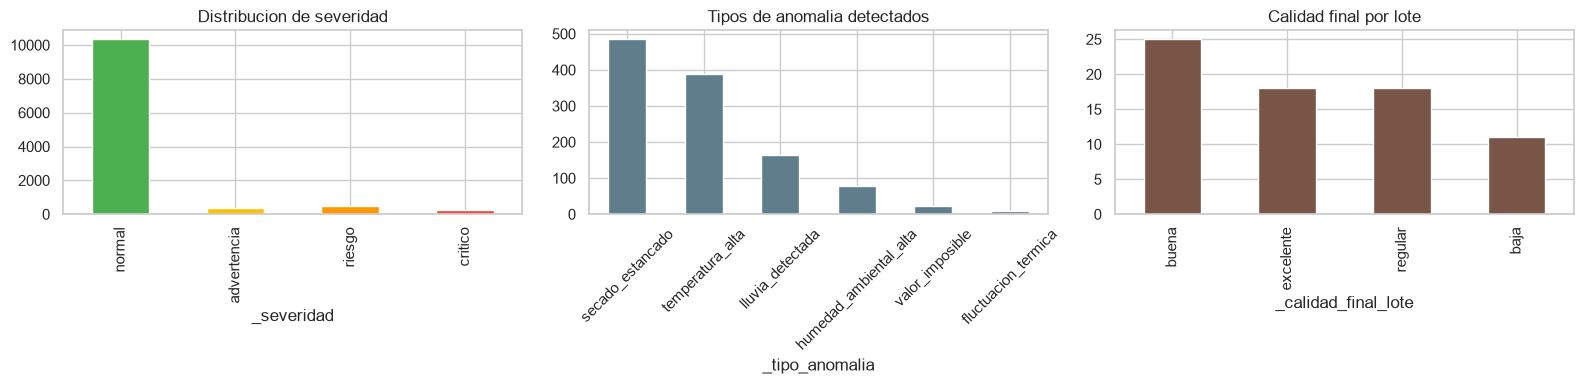

In [6]:
# Dibuja un bar plot con `conteo` (una Series de value_counts). Si `conteo` viene vacio
# (0 categorias), pandas/matplotlib truenan con IndexError al intentar poner los ticks del
# eje X. Esto puede pasar si esta celda se corre con un `df` que, por la razon que sea
# (p.ej. se re-ejecuto la generacion con menos lotes, o una muestra sin anomalias), no tiene
# ninguna fila que graficar. En vez de dejar que truene, se muestra un aviso.
def _bar_o_aviso(ax, conteo, titulo, color):
    if len(conteo) == 0:
        ax.text(0.5, 0.5, "Sin datos para graficar", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        conteo.plot(kind="bar", ax=ax, color=color)
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

conteo_severidad = df["_severidad"].value_counts().reindex(["normal", "advertencia", "riesgo", "critico"]).fillna(0)
_bar_o_aviso(axes[0], conteo_severidad, "Distribucion de severidad", ["#4CAF50", "#FFC107", "#FF9800", "#F44336"])

conteo_tipo_anomalia = df.loc[df["_es_anomalia"], "_tipo_anomalia"].value_counts()
_bar_o_aviso(axes[1], conteo_tipo_anomalia, "Tipos de anomalia detectados", "#607D8B")
axes[1].tick_params(axis="x", rotation=45)

conteo_calidad = df.drop_duplicates("id_lote")["_calidad_final_lote"].value_counts()
_bar_o_aviso(axes[2], conteo_calidad, "Calidad final por lote", "#795548")

plt.tight_layout()
plt.show()

### 0.6 Preprocesamiento (`scripts/train_models.py::cargar_y_limpiar`)

Se imputan los nulos de sensores con la mediana, se calcula el feature derivado `delta_temp`,
y se define el `ColumnTransformer` que codifica `tipo_proceso` con one-hot. Este preprocesamiento
es **compartido**: lo usan los 3 modelos supervisados de la Parte B (la Parte A usa solo las
columnas numericas, sin necesitar el one-hot).

In [7]:
NUMERIC_FEATURES = ["temperatura_grano", "temperatura_ambiental", "humedad_ambiental", "humedad_grano", "lluvia", "luz", "delta_temp"]
CATEGORICAL_FEATURES = ["tipo_proceso"]

def cargar_y_limpiar(df_raw):
    df_ = df_raw.dropna(subset=["tipo_proceso", "id_lote"]).copy()
    for col in ["temperatura_grano", "temperatura_ambiental", "humedad_ambiental", "humedad_grano", "lluvia", "luz"]:
        mediana = df_[col].median()
        if pd.isna(mediana):
            mediana = 0.0  # respaldo extremo: solo pasaria si la columna entera fuera NaN
        df_[col] = df_[col].fillna(mediana)
    df_["delta_temp"] = df_["temperatura_grano"] - df_["temperatura_ambiental"]
    # Salvaguarda final (defensiva): elimina cualquier fila que, por cualquier motivo no
    # previsto (version de pandas/numpy distinta, dato corrupto, etc.), conserve un NaN en
    # alguna columna critica para el entrenamiento -features o etiquetas-. En condiciones
    # normales esto elimina 0 filas; si alguna vez elimina mas de 0, se imprime un aviso para
    # que sea visible en vez de que sklearn truene mas adelante con un error generico.
    columnas_criticas = [
        "temperatura_grano", "temperatura_ambiental", "humedad_ambiental", "humedad_grano",
        "lluvia", "luz", "delta_temp", "tipo_proceso", "horas_transcurridas",
        "horas_restantes", "_tipo_anomalia", "_calidad_final_lote",
    ]
    columnas_presentes = [c for c in columnas_criticas if c in df_.columns]
    filas_antes = len(df_)
    df_ = df_.dropna(subset=columnas_presentes).reset_index(drop=True)
    filas_eliminadas = filas_antes - len(df_)
    if filas_eliminadas > 0:
        print(f"[aviso] cargar_y_limpiar elimino {filas_eliminadas} fila(s) con NaN residual "
              f"en columnas criticas (no deberia pasar en condiciones normales).")
    return df_

df_limpio = cargar_y_limpiar(df)
print("Filas antes de limpiar:", len(df), " | despues:", len(df_limpio))
print("Nulos restantes en features numericas:")
print(df_limpio[NUMERIC_FEATURES].isna().sum())

def _preprocesador():
    return ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)], remainder="passthrough")

df_limpio[CATEGORICAL_FEATURES + NUMERIC_FEATURES].head()

Filas antes de limpiar: 11491  | despues: 11491
Nulos restantes en features numericas:
temperatura_grano        0
temperatura_ambiental    0
humedad_ambiental        0
humedad_grano            0
lluvia                   0
luz                      0
delta_temp               0
dtype: int64


,tipo_proceso,temperatura_grano,temperatura_ambiental,humedad_ambiental,humedad_grano,lluvia,luz,delta_temp
0,lavado,24.48,21.62,58.01,41.39,0.0,0.0,2.86
1,lavado,24.66,23.34,57.64,16.13,0.0,0.0,1.32
2,lavado,36.20,32.23,43.58,31.25,0.0,65581.5,3.97
3,natural,28.94,28.88,52.82,20.77,0.0,5014.6,0.06
4,lavado,22.80,20.24,51.93,40.28,0.0,0.0,2.56


### 0.7 Como comprobamos que los datos estan bien

Antes de entrenar nada (ni en Parte A ni en Parte B), se valida el dataset ya limpio con
comprobaciones automaticas (no basta con "verlo" en un `.head()`; si alguna de estas asserts
falla, la celda truena a proposito para no seguir entrenando con datos malos):

In [8]:
print("=== Validacion de la estructura y calidad de los datos ===")

# 1) Estructura: estan todas las columnas que el resto del notebook espera encontrar
columnas_esperadas = {
    "id_lote", "tipo_proceso", "horas_transcurridas", "horas_restantes",
    "temperatura_grano", "temperatura_ambiental", "humedad_ambiental", "humedad_grano",
    "lluvia", "luz", "_es_anomalia", "_severidad", "_tipo_anomalia",
    "_calidad_final_lote", "delta_temp",
}
faltantes = columnas_esperadas - set(df_limpio.columns)
assert not faltantes, f"Faltan columnas esperadas: {faltantes}"
print("[OK] Estructura: estan todas las columnas esperadas.")

# 2) Nulos: la limpieza (imputacion por mediana) debio dejar el dataset en cero nulos
nulos_restantes = int(df_limpio[NUMERIC_FEATURES].isna().sum().sum())
assert nulos_restantes == 0, f"Quedaron {nulos_restantes} nulos sin limpiar en las features numericas"
print("[OK] Nulos: cero nulos en las features numericas despues de la limpieza.")

# 3) Rangos fisicamente posibles (coherente con clasificar_valor_imposible de rules.py).
# OJO: aqui NO se exige que el 100% de las filas esten en rango. El generador
# (simular_lote) inyecta a proposito fallos de sensor ("valor_imposible", ~0.4% de las
# lecturas) que ponen humedad_ambiental en un valor negativo imposible -precisamente para
# que el motor de reglas aprenda a detectarlos como criticos. Si exigieramos cero valores
# fuera de rango, estariamos borrando la señal que el modelo necesita para reconocer
# sensores rotos. Lo que SI se valida es: (a) que sean una fraccion minima de los datos, y
# (b) que absolutamente TODOS esos casos hayan quedado marcados como "critico" por las
# reglas (si alguno se escapara sin marcar, ahi si seria un bug real).
rangos_validos = {
    "humedad_ambiental": (0, 100),
    "humedad_grano": (0, 100),
    "lluvia": (0, 1.01),
    "luz": (0, None),
}
for col, (lo, hi) in rangos_validos.items():
    condicion_fuera = (df_limpio[col] < lo) | ((df_limpio[col] > hi) if hi is not None else False)
    n_fuera = int(condicion_fuera.sum())
    frac_fuera = n_fuera / len(df_limpio)
    assert frac_fuera < 0.01, (
        f"{frac_fuera:.2%} de las filas tienen '{col}' fuera de rango fisico - "
        f"demasiadas para ser solo fallos de sensor simulados (se esperaba <1%)"
    )
    if n_fuera > 0:
        no_marcadas = int((df_limpio.loc[condicion_fuera, "_severidad"] != "critico").sum())
        assert no_marcadas == 0, (
            f"{no_marcadas} filas con '{col}' fuera de rango NO quedaron marcadas como criticas "
            f"por las reglas de dominio (deberian estarlo siempre)"
        )
        print(f"[OK] '{col}': {n_fuera} filas fuera de rango ({frac_fuera:.2%}), y las {n_fuera} "
              f"quedaron correctamente marcadas como 'critico' por las reglas.")
print("[OK] Rangos: los valores fuera de rango fisico (fallos de sensor a proposito) son una "
      "fraccion minima y TODOS estan correctamente detectados como criticos.")

# 4) Duplicados: no debe haber dos lecturas con el mismo lote a la misma hora transcurrida
duplicados = int(df_limpio.duplicated(subset=["id_lote", "horas_transcurridas"]).sum())
assert duplicados == 0, f"Hay {duplicados} lecturas duplicadas (mismo lote y misma hora)"
print("[OK] Duplicados: no hay lecturas repetidas (id_lote + horas_transcurridas es unico).")

# 5) Balance de clases: el rebalanceo de generar_dataset.py apunta a ~10% de anomalias
balance = float(df_limpio["_es_anomalia"].mean())
assert 0.05 <= balance <= 0.20, f"El balance normal/anomalia se salio del rango esperado: {balance:.1%}"
print(f"[OK] Balance de clases: {balance:.1%} de anomalias, dentro del ~10% esperado.")

# 6) Categorias validas: tipo_proceso solo puede ser uno de los 3 procesos del dominio
tipos_validos = {"lavado", "honey", "natural"}
tipos_encontrados = set(df_limpio["tipo_proceso"].unique())
tipos_invalidos = tipos_encontrados - tipos_validos
assert not tipos_invalidos, f"tipo_proceso tiene valores inesperados: {tipos_invalidos}"
print(f"[OK] Categorias: tipo_proceso solo contiene valores validos {sorted(tipos_encontrados)}.")

print("\nTodas las validaciones de calidad de datos pasaron. Se puede entrenar con confianza.")

=== Validacion de la estructura y calidad de los datos ===
[OK] Estructura: estan todas las columnas esperadas.
[OK] Nulos: cero nulos en las features numericas despues de la limpieza.
[OK] 'humedad_ambiental': 10 filas fuera de rango (0.09%), y las 10 quedaron correctamente marcadas como 'critico' por las reglas.
[OK] Rangos: los valores fuera de rango fisico (fallos de sensor a proposito) son una fraccion minima y TODOS estan correctamente detectados como criticos.
[OK] Duplicados: no hay lecturas repetidas (id_lote + horas_transcurridas es unico).
[OK] Balance de clases: 10.0% de anomalias, dentro del ~10% esperado.
[OK] Categorias: tipo_proceso solo contiene valores validos ['honey', 'lavado', 'natural'].

Todas las validaciones de calidad de datos pasaron. Se puede entrenar con confianza.


---

## PARTE A - APRENDIZAJE NO SUPERVISADO

### A.1 Que significa "no supervisado" aqui

El modelo de esta parte, `IsolationForest`, **nunca recibe una etiqueta** (`y`) al entrenar.
Solo recibe las features numericas (`X`) y aprende, el solo, la forma general de la nube de
puntos "normales". Cualquier punto que se aleje mucho de esa forma se marca como *outlier*.
No hay "respuesta correcta" que el modelo intente reproducir - por eso es no supervisado.

Es el algoritmo correcto para esto porque el objetivo es **detectar lo inesperado**: patrones
raros que ni siquiera sabiamos que buscar de antemano. Los otros 3 modelos (Parte B) si saben
exactamente que predecir porque los entrenamos con la respuesta ya conocida.

### A.2 Algoritmo y entrenamiento (`IsolationForest`)

Solo hay un modelo en esta parte, asi que se entrena solo (la concurrencia real esta en la
Parte B, donde SI hay 3 modelos independientes que conviene paralelizar).

In [9]:
def entrenar_isolation_forest(df_):
    X = df_[NUMERIC_FEATURES]
    contamination = float(np.clip(df_["_es_anomalia"].mean(), 0.02, 0.3))
    modelo = IsolationForest(contamination=contamination, random_state=42, n_estimators=200, n_jobs=1)
    modelo.fit(X)  # <- no recibe "y": no hay etiqueta que aprender. Esto es NO SUPERVISADO.
    pred = modelo.predict(X)
    tasa_outliers = (pred == -1).mean()
    return modelo, {"contamination": contamination, "tasa_outliers_detectados": round(float(tasa_outliers), 4)}

_t0 = time.time()
isolation_model, metricas_if = entrenar_isolation_forest(df_limpio)
print("IsolationForest (NO SUPERVISADO):", metricas_if)
print(f"Tiempo de entrenamiento: {time.time() - _t0:.1f} segundos.")

IsolationForest (NO SUPERVISADO): {'contamination': 0.09999129753720302, 'tasa_outliers_detectados': 0.1}
Tiempo de entrenamiento: 0.4 segundos.


### A.3 Evaluacion

Un modelo no supervisado no tiene "accuracy" en sentido estricto (no hay etiqueta que
predecir), pero si podemos hacer una **validacion externa post-hoc**: comparar, solo para
verificar, si lo que el modelo marco como outlier coincide con lo que las reglas de dominio
(`_es_anomalia`) ya sabian que era anomalo. Esta comparacion **no se usa para entrenar** (el
modelo jamas vio `_es_anomalia`); es unicamente para inspeccionar que tan razonable es lo que
aprendio por su cuenta.

In [10]:
pred_if = isolation_model.predict(df_limpio[NUMERIC_FEATURES])
df_limpio["_outlier_isolation_forest"] = pred_if == -1

tabla_cruzada = pd.crosstab(
    df_limpio["_es_anomalia"].map({True: "regla: anomalia", False: "regla: normal"}),
    df_limpio["_outlier_isolation_forest"].map({True: "IF: outlier", False: "IF: normal"}),
)
print("Tabla cruzada (validacion externa, NO usada para entrenar):")
print(tabla_cruzada)

coincidencia = float((df_limpio["_es_anomalia"] == df_limpio["_outlier_isolation_forest"]).mean())
print(f"\nCoincidencia con el criterio de reglas: {coincidencia:.1%}")
print("(No se espera 100%: el IsolationForest puede encontrar anomalias distintas a las que")
print(" cubren las reglas explicitas - esa es justamente la ventaja de tener ambos.)")

Tabla cruzada (validacion externa, NO usada para entrenar):
_outlier_isolation_forest  IF: normal  IF: outlier
_es_anomalia                                      
regla: anomalia                   597          552
regla: normal                    9745          597

Coincidencia con el criterio de reglas: 89.6%
(No se espera 100%: el IsolationForest puede encontrar anomalias distintas a las que
 cubren las reglas explicitas - esa es justamente la ventaja de tener ambos.)


### A.4 Prediccion / visualizacion

Se toma una muestra del dataset y se pinta cuales lecturas el modelo marca como outlier (rojo)
vs. normales (verde), coloreando **unicamente con la salida del propio modelo** (no con la
etiqueta de reglas).

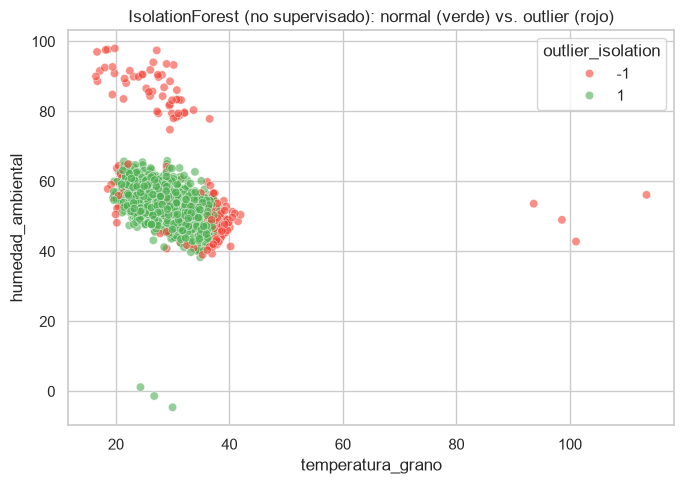

In [11]:
sample = df_limpio.sample(min(3000, len(df_limpio)), random_state=42).copy()
X_sample = sample[NUMERIC_FEATURES]
sample["outlier_isolation"] = isolation_model.predict(X_sample)
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sample, x="temperatura_grano", y="humedad_ambiental", hue="outlier_isolation",
                 palette={1: "#4CAF50", -1: "#F44336"}, alpha=0.6, ax=ax)
ax.set_title("IsolationForest (no supervisado): normal (verde) vs. outlier (rojo)")
plt.tight_layout()
plt.show()

---

## PARTE B - APRENDIZAJE SUPERVISADO

### B.1 Que significa "supervisado" aqui

Los 3 modelos de esta parte son `RandomForestClassifier` (x2) y `RandomForestRegressor` (x1).
A los 3, al entrenar, se les da **tanto las features (`X`) como la respuesta correcta ya
conocida (`y`)**: el tipo de anomalia, las horas restantes reales, o la calidad final real de
cada lote (todas calculadas por las reglas de dominio o por la simulacion). El modelo ajusta
sus arboles para reproducir esa respuesta lo mejor posible en datos que no vio. Por eso es
supervisado: aprende **comparando contra una respuesta ya conocida**, no descubriendo patrones
por su cuenta como en la Parte A.

En los 3 se usa `GroupShuffleSplit` agrupado por `id_lote` (no por fila), para que ningun lote
quede repartido entre entrenamiento y prueba - si una fila de un lote esta en train y otra del
mismo lote en test, el modelo podria "hacer trampa" aprendiendo el lote en vez del patron
general.

### B.2 Algoritmo y entrenamiento (3 x `RandomForest`, en paralelo)

Se definen las 3 funciones de entrenamiento y luego se lanzan **las 3 a la vez** con
`ThreadPoolExecutor`, porque son completamente independientes entre si (ninguna necesita el
resultado de otra).

In [12]:
def _verificar_sin_nans(X, y, nombre_modelo):
    # Convierte un posible NaN residual en un mensaje claro y accionable, en vez de dejar que
    # sklearn truene con "ValueError: Input contains NaN" sin decir en que modelo ni por que.
    filas_malas_X = int(X.isna().any(axis=1).sum())
    filas_malas_y = int(pd.isna(y).sum())
    if filas_malas_X or filas_malas_y:
        columnas_con_nan = list(X.columns[X.isna().any()])
        raise ValueError(
            f"[{nombre_modelo}] Se encontraron valores NaN antes de entrenar: "
            f"{filas_malas_X} fila(s) con NaN en features (columnas: {columnas_con_nan}), "
            f"{filas_malas_y} fila(s) con NaN en la etiqueta. Esto no deberia pasar despues de "
            f"cargar_y_limpiar(); revisa el dataset o vuelve a correr la Parte 0 desde el inicio."
        )

def entrenar_clasificador_tipo(df_):
    cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES
    X = df_[cols]
    y = df_["_tipo_anomalia"]  # <- etiqueta conocida -> SUPERVISADO
    groups = df_["id_lote"]
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    _verificar_sin_nans(X.iloc[train_idx], y.iloc[train_idx], "entrenar_clasificador_tipo")
    pipe = Pipeline([("prep", _preprocesador()),
                      ("clf", RandomForestClassifier(n_estimators=150, max_depth=14, class_weight="balanced_subsample", random_state=42, n_jobs=1))])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_holdout = pipe.predict(X.iloc[test_idx])
    y_test_holdout = y.iloc[test_idx].reset_index(drop=True)
    metricas = {"accuracy": round(float(accuracy_score(y_test_holdout, y_pred_holdout)), 4),
                "f1_macro": round(float(f1_score(y_test_holdout, y_pred_holdout, average="macro")), 4)}
    holdout = {"y_true": y_test_holdout, "y_pred": pd.Series(y_pred_holdout), "clases": sorted(y.unique())}
    pipe.fit(X, y)
    return pipe, metricas, holdout

print("Funcion de RandomForestClassifier (tipo_anomalia) definida (se entrena mas abajo, en paralelo).")

Funcion de RandomForestClassifier (tipo_anomalia) definida (se entrena mas abajo, en paralelo).


In [13]:
def entrenar_regresor_tiempo(df_):
    cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES + ["horas_transcurridas"]
    X = df_[cols]
    y = df_["horas_restantes"]  # <- etiqueta numerica conocida -> SUPERVISADO (regresion)
    groups = df_["id_lote"]
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    _verificar_sin_nans(X.iloc[train_idx], y.iloc[train_idx], "entrenar_regresor_tiempo")
    pipe = Pipeline([("prep", _preprocesador()), ("reg", RandomForestRegressor(n_estimators=150, max_depth=16, random_state=42, n_jobs=1))])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_holdout = pipe.predict(X.iloc[test_idx])
    y_test_holdout = y.iloc[test_idx].reset_index(drop=True)
    rmse = float(np.sqrt(mean_squared_error(y_test_holdout, y_pred_holdout)))
    mae = float(mean_absolute_error(y_test_holdout, y_pred_holdout))
    metricas = {"rmse_horas": round(rmse, 2), "mae_horas": round(mae, 2)}
    holdout = {"y_true": y_test_holdout, "y_pred": pd.Series(y_pred_holdout)}
    pipe.fit(X, y)
    return pipe, metricas, holdout

print("Funcion de RandomForestRegressor (tiempo_restante) definida (se entrena mas abajo, en paralelo).")

Funcion de RandomForestRegressor (tiempo_restante) definida (se entrena mas abajo, en paralelo).


In [14]:
def entrenar_clasificador_calidad(df_):
    cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES + ["horas_transcurridas"]
    X = df_[cols]
    y = df_["_calidad_final_lote"].astype(str)  # <- etiqueta conocida -> SUPERVISADO
    groups = df_["id_lote"]
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))
    _verificar_sin_nans(X.iloc[train_idx], y.iloc[train_idx], "entrenar_clasificador_calidad")
    pipe = Pipeline([("prep", _preprocesador()),
                      ("clf", RandomForestClassifier(n_estimators=150, max_depth=12, class_weight="balanced_subsample", random_state=42, n_jobs=1))])
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_holdout = pipe.predict(X.iloc[test_idx])
    y_test_holdout = y.iloc[test_idx].reset_index(drop=True)
    metricas = {"accuracy": round(float(accuracy_score(y_test_holdout, y_pred_holdout)), 4),
                "f1_macro": round(float(f1_score(y_test_holdout, y_pred_holdout, average="macro")), 4)}
    holdout = {"y_true": y_test_holdout, "y_pred": pd.Series(y_pred_holdout), "clases": sorted(y.unique())}
    pipe.fit(X, y)
    return pipe, metricas, holdout

print("Funcion de RandomForestClassifier (calidad_final) definida (se entrena mas abajo, en paralelo).")

Funcion de RandomForestClassifier (calidad_final) definida (se entrena mas abajo, en paralelo).


In [15]:
# CONCURRENCIA (2 de 2 en el notebook): los 3 entrenamientos de arriba son independientes
# entre si (ninguno necesita el resultado de otro; todos parten unicamente de df_limpio), asi
# que en vez de llamarlos uno tras otro se lanzan los 3 al mismo tiempo con ThreadPoolExecutor.
# Se usan hilos (no procesos) por la misma razon de siempre: evitar el overhead/riesgo de
# Windows al abrir procesos nuevos dentro de Jupyter. Cada RandomForest se queda con n_jobs=1
# individualmente a proposito -no tendria sentido paralelizar CADA modelo por dentro (con
# procesos) Y los 3 modelos entre si al mismo tiempo (con hilos): eso anidaria dos niveles de
# paralelismo y en Windows especificamente el nivel de procesos (n_jobs=-1) es el que causaba
# cuelgues/lentitud. Con hilos afuera y n_jobs=1 adentro, sklearn igual libera el GIL durante el
# computo pesado en C/Cython, asi que los 3 entrenamientos si corren en paralelo aprovechando
# varios nucleos.
_t0 = time.time()
with ThreadPoolExecutor(max_workers=3) as executor:
    futuro_tipo = executor.submit(entrenar_clasificador_tipo, df_limpio)
    futuro_regresor = executor.submit(entrenar_regresor_tiempo, df_limpio)
    futuro_calidad = executor.submit(entrenar_clasificador_calidad, df_limpio)

    rf_tipo, metricas_tipo, holdout_tipo = futuro_tipo.result()
    rf_tiempo, metricas_tiempo, holdout_tiempo = futuro_regresor.result()
    rf_calidad, metricas_calidad, holdout_calidad = futuro_calidad.result()
_tiempo_total_entrenamiento = time.time() - _t0

print("RandomForestClassifier tipo_anomalia (SUPERVISADO, holdout por lote):", metricas_tipo)
print("RandomForestRegressor tiempo_restante (SUPERVISADO, holdout por lote):", metricas_tiempo)
print("RandomForestClassifier calidad_final (SUPERVISADO, holdout por lote):", metricas_calidad)
print(f"\nTiempo total de los 3 entrenamientos EN PARALELO (3 hilos): {_tiempo_total_entrenamiento:.1f} segundos.")

RandomForestClassifier tipo_anomalia (SUPERVISADO, holdout por lote): {'accuracy': 0.8761, 'f1_macro': 0.7071}
RandomForestRegressor tiempo_restante (SUPERVISADO, holdout por lote): {'rmse_horas': 54.13, 'mae_horas': 33.55}
RandomForestClassifier calidad_final (SUPERVISADO, holdout por lote): {'accuracy': 0.3887, 'f1_macro': 0.3854}

Tiempo total de los 3 entrenamientos EN PARALELO (3 hilos): 16.3 segundos.


### B.3 Evaluacion reforzada

Ademas de accuracy/f1/RMSE/MAE, se agregan 3 cosas que un modelo supervisado si permite hacer
(y que en la Parte A no aplican porque no hay etiqueta contra que comparar): matriz de
confusion, reporte de clasificacion por clase, e importancia de cada feature.

In [16]:
resumen_metricas = pd.DataFrame([
    {"modelo": "RandomForestClassifier (tipo_anomalia)", "tarea": "Clasificacion", **metricas_tipo},
    {"modelo": "RandomForestRegressor (tiempo_restante)", "tarea": "Regresion", **metricas_tiempo},
    {"modelo": "RandomForestClassifier (calidad_final)", "tarea": "Clasificacion", **metricas_calidad},
])
resumen_metricas

,modelo,tarea,accuracy,f1_macro,rmse_horas,mae_horas
0,RandomForestClassifier (tipo_anomalia),Clasificacion,0.8761,0.7071,NaN,NaN
1,RandomForestRegressor (tiempo_restante),Regresion,NaN,NaN,54.13,33.55
2,RandomForestClassifier (calidad_final),Clasificacion,0.3887,0.3854,NaN,NaN


In [17]:
print("=== Reporte de clasificacion: tipo_anomalia (holdout por lote) ===")
print(classification_report(holdout_tipo["y_true"], holdout_tipo["y_pred"], zero_division=0))

print("\n=== Reporte de clasificacion: calidad_final (holdout por lote) ===")
print(classification_report(holdout_calidad["y_true"], holdout_calidad["y_pred"], zero_division=0))

=== Reporte de clasificacion: tipo_anomalia (holdout por lote) ===
                        precision    recall  f1-score   support

   fluctuacion_termica       0.00      0.00      0.00         1
humedad_ambiental_alta       0.94      0.94      0.94        18
      lluvia_detectada       0.97      1.00      0.99        33
                normal       0.97      0.90      0.93      2307
      secado_estancado       0.09      0.24      0.13        97
      temperatura_alta       0.94      0.99      0.96        73
       valor_imposible       1.00      1.00      1.00         5

              accuracy                           0.88      2534
             macro avg       0.70      0.72      0.71      2534
          weighted avg       0.93      0.88      0.90      2534


=== Reporte de clasificacion: calidad_final (holdout por lote) ===
              precision    recall  f1-score   support

        baja       0.28      0.77      0.41       278
       buena       0.45      0.26      0.33      

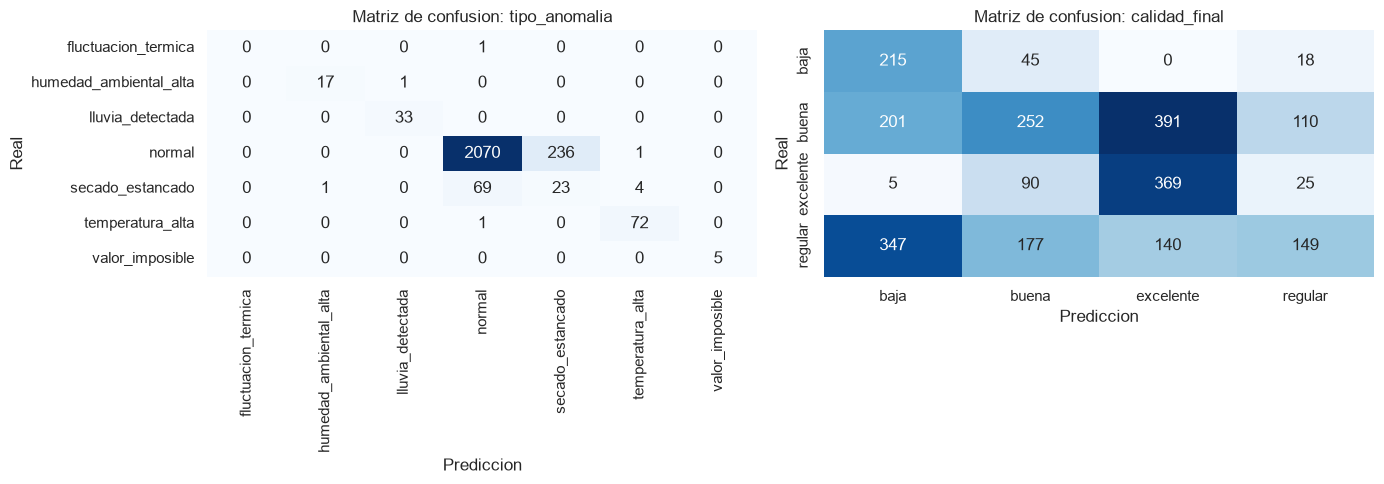

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, holdout, titulo in [
    (axes[0], holdout_tipo, "Matriz de confusion: tipo_anomalia"),
    (axes[1], holdout_calidad, "Matriz de confusion: calidad_final"),
]:
    clases = holdout["clases"]
    cm = confusion_matrix(holdout["y_true"], holdout["y_pred"], labels=clases)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clases, yticklabels=clases, ax=ax, cbar=False)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

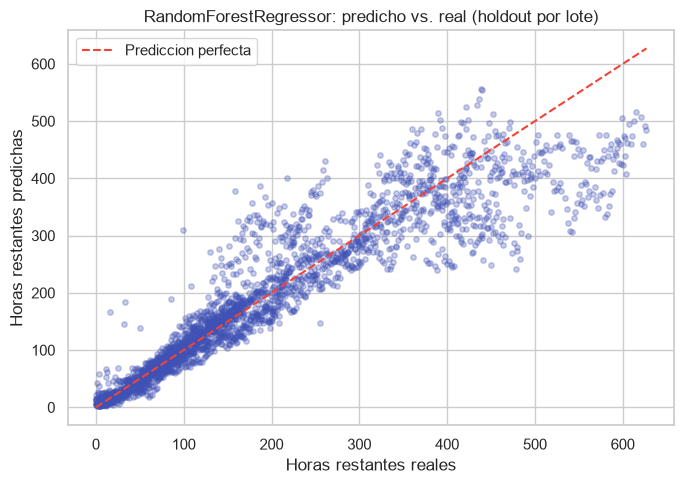

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
y_true_h = holdout_tiempo["y_true"]
y_pred_h = holdout_tiempo["y_pred"]
ax.scatter(y_true_h, y_pred_h, alpha=0.3, s=15, color="#3F51B5")
lim = [0, max(y_true_h.max(), y_pred_h.max())]
ax.plot(lim, lim, "--", color="#F44336", label="Prediccion perfecta")
ax.set_xlabel("Horas restantes reales")
ax.set_ylabel("Horas restantes predichas")
ax.set_title("RandomForestRegressor: predicho vs. real (holdout por lote)")
ax.legend()
plt.tight_layout()
plt.show()

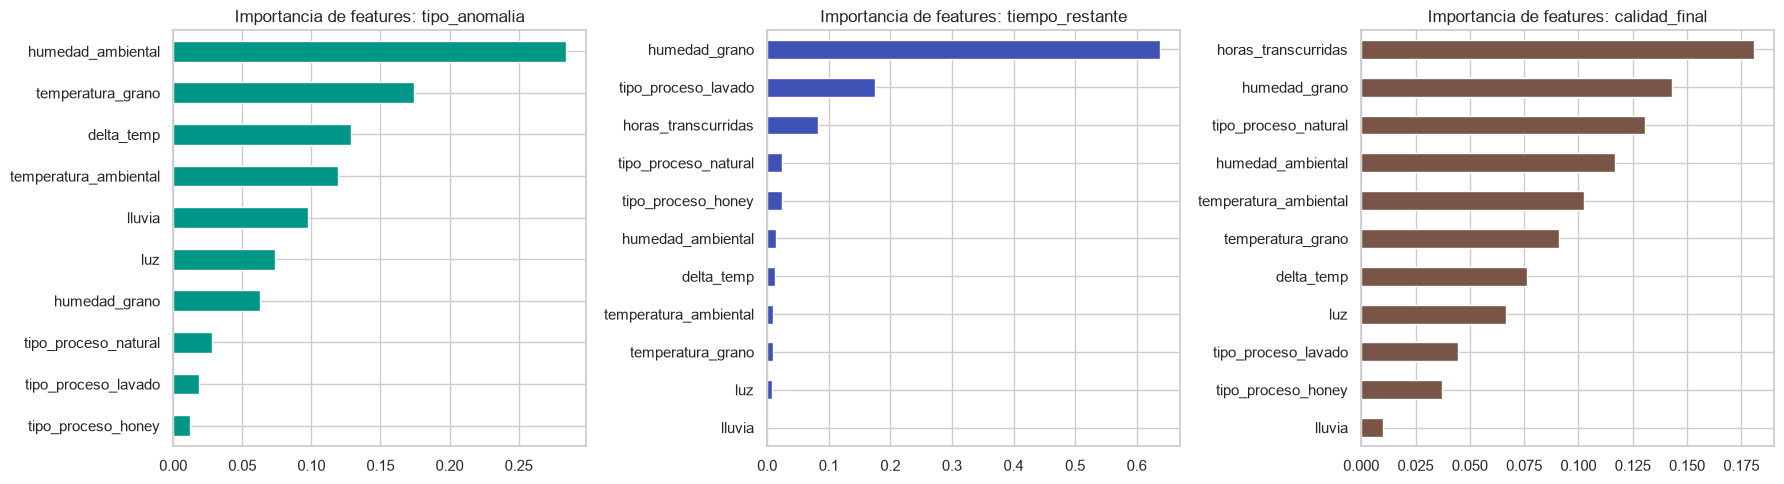

In [20]:
def _importancias(pipe, cols_categoricas, cols_numericas, atributo):
    nombres = list(pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cols_categoricas)) + cols_numericas
    importancias = getattr(pipe.named_steps[atributo], "feature_importances_")
    return pd.Series(importancias, index=nombres).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
imp_tipo = _importancias(rf_tipo, CATEGORICAL_FEATURES, NUMERIC_FEATURES, "clf")
imp_tipo.plot(kind="barh", ax=axes[0], color="#009688")
axes[0].set_title("Importancia de features: tipo_anomalia")
axes[0].invert_yaxis()

imp_tiempo = _importancias(rf_tiempo, CATEGORICAL_FEATURES, NUMERIC_FEATURES + ["horas_transcurridas"], "reg")
imp_tiempo.plot(kind="barh", ax=axes[1], color="#3F51B5")
axes[1].set_title("Importancia de features: tiempo_restante")
axes[1].invert_yaxis()

imp_calidad = _importancias(rf_calidad, CATEGORICAL_FEATURES, NUMERIC_FEATURES + ["horas_transcurridas"], "clf")
imp_calidad.plot(kind="barh", ax=axes[2], color="#795548")
axes[2].set_title("Importancia de features: calidad_final")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

---

## PARTE C - Ensamble de produccion y prueba con la API real

Todo lo anterior entrena modelos sueltos. En produccion, `app/services/anomaly_detector.py` y
`app/services/predictor.py` combinan reglas + Parte A + Parte B en un solo ensamble, y ese
ensamble se expone via HTTP en `app/api/routes/inference.py`. Aqui se reconstruye ese ensamble
y, a diferencia de las versiones anteriores de este notebook, **se prueba a traves de un
endpoint HTTP real** (no solo llamando funciones de Python sueltas).

In [21]:
def anomaly_detector_predict(tipo_proceso, features, delta_temp_reciente=None, delta_humedad_grano_24h=None):
    tipo_proceso = (tipo_proceso or "lavado").lower()
    regla = evaluar_lectura(tipo_proceso, features, delta_temp_reciente=delta_temp_reciente, delta_humedad_grano_24h=delta_humedad_grano_24h)
    fila = pd.DataFrame([{
        "tipo_proceso": tipo_proceso,
        "temperatura_grano": features["temperatura_grano"],
        "temperatura_ambiental": features["temperatura_ambiental"],
        "humedad_ambiental": features["humedad_ambiental"],
        "humedad_grano": features["humedad_grano"],
        "lluvia": features["lluvia"],
        "luz": features["luz"],
        "delta_temp": features["temperatura_grano"] - features["temperatura_ambiental"],
    }])
    proba = rf_tipo.predict_proba(fila)[0]
    clases = rf_tipo.named_steps["clf"].classes_
    idx = proba.argmax()
    tipo_ml, confianza_ml = clases[idx], float(proba[idx])
    fila_if = fila[NUMERIC_FEATURES]
    outlier_ml = bool(isolation_model.predict(fila_if)[0] == -1)
    score_if = float(isolation_model.decision_function(fila_if)[0])
    severidad_ml = TIPO_SEVERIDAD_DEFAULT.get(tipo_ml, "normal")
    if regla["severidad"] == "normal" and tipo_ml != "normal":
        severidad_final = peor_severidad(regla["severidad"], severidad_ml)
    else:
        severidad_final = regla["severidad"]
    variables = set(regla["variables_contribuyentes"])
    alertas = list(regla["alertas"])
    if outlier_ml and not regla["alertas"]:
        variables.add("patron_atipico_ml")
        alertas.append({"tipo": "patron_atipico_ml", "severidad": "advertencia",
                         "mensaje": "El modelo detecto un patron fuera de lo comun no cubierto por las reglas explicitas.",
                         "variable": "patron_atipico_ml"})
        severidad_final = peor_severidad(severidad_final, "advertencia")
    es_anomalia = severidad_final != "normal" or outlier_ml
    tipo_principal = regla["tipo_principal"] if regla["tipo_principal"] != "normal" else tipo_ml
    return {"es_anomalia": es_anomalia, "severidad": severidad_final, "tipo_principal": tipo_principal,
            "variables_contribuyentes": sorted(variables) or ["sin_datos"], "alertas": alertas,
            "score_isolation_forest": round(score_if, 4), "confianza_ml": round(confianza_ml * 100, 1)}

def predictor_predecir(tipo_proceso, features, horas_transcurridas=0.0):
    tipo_proceso = (tipo_proceso or "lavado").lower()
    fila = pd.DataFrame([{
        "tipo_proceso": tipo_proceso,
        "temperatura_grano": features["temperatura_grano"],
        "temperatura_ambiental": features["temperatura_ambiental"],
        "humedad_ambiental": features["humedad_ambiental"],
        "humedad_grano": features["humedad_grano"],
        "lluvia": features["lluvia"],
        "luz": features["luz"],
        "delta_temp": features["temperatura_grano"] - features["temperatura_ambiental"],
        "horas_transcurridas": horas_transcurridas,
    }])
    tiempo_estimado_horas = round(max(float(rf_tiempo.predict(fila)[0]), 0.0), 1)
    proba = rf_calidad.predict_proba(fila)[0]
    clases = rf_calidad.named_steps["clf"].classes_
    idx = proba.argmax()
    return {"tiempo_estimado_horas": tiempo_estimado_horas, "calidad_estimada": str(clases[idx]), "confianza": round(float(proba[idx]) * 100, 1)}

print("Funciones de inferencia (ensamble reglas + Parte A + Parte B) listas.")

Funciones de inferencia (ensamble reglas + Parte A + Parte B) listas.


### C.1 Casos de prueba directos (equivalentes a `tests/test_api.py`)

Primero se prueba el ensamble como funciones de Python sueltas, sobre 4 escenarios que cubren
normal, advertencia leve, critico por lluvia y critico por sensor con valor imposible.

In [22]:
casos_prueba = {
    "Normal": {
        "tipo_proceso": "lavado",
        "lecturas": {"temperatura_grano": 27.0, "temperatura_ambiental": 25.0, "humedad_ambiental": 50.0, "humedad_grano": 30.0, "lluvia": 0.0, "luz": 40000},
    },
    "Advertencia leve (temperatura alta)": {
        "tipo_proceso": "lavado",
        "lecturas": {"temperatura_grano": 36.0, "temperatura_ambiental": 30.0, "humedad_ambiental": 55.0, "humedad_grano": 30.0, "lluvia": 0.0, "luz": 40000},
    },
    "Critico (lluvia detectada)": {
        "tipo_proceso": "lavado",
        "lecturas": {"temperatura_grano": 30.0, "temperatura_ambiental": 26.0, "humedad_ambiental": 70.0, "humedad_grano": 40.0, "lluvia": 0.9, "luz": 5000},
    },
    "Critico (valor imposible del sensor)": {
        "tipo_proceso": "natural",
        "lecturas": {"temperatura_grano": 105.0, "temperatura_ambiental": 28.0, "humedad_ambiental": 60.0, "humedad_grano": 35.0, "lluvia": 0.0, "luz": 20000},
    },
}

resultados_prueba = {}
for nombre, caso in casos_prueba.items():
    resultado = anomaly_detector_predict(caso["tipo_proceso"], caso["lecturas"])
    prediccion = predictor_predecir(caso["tipo_proceso"], caso["lecturas"], horas_transcurridas=48.0)
    resultados_prueba[nombre] = (resultado, prediccion)
    print(f"--- {nombre} ---")
    print(f"  es_anomalia={resultado['es_anomalia']}  severidad={resultado['severidad']}  tipo_principal={resultado['tipo_principal']}")
    print(f"  confianza_ml={resultado['confianza_ml']}%  score_isolation_forest={resultado['score_isolation_forest']}")
    print(f"  tiempo_estimado_horas={prediccion['tiempo_estimado_horas']}  calidad_estimada={prediccion['calidad_estimada']} ({prediccion['confianza']}%)")
    print()

r_normal = resultados_prueba["Normal"][0]
r_advertencia = resultados_prueba["Advertencia leve (temperatura alta)"][0]
r_critico = resultados_prueba["Critico (lluvia detectada)"][0]
r_critico_sensor = resultados_prueba["Critico (valor imposible del sensor)"][0]

assert r_normal["severidad"] == "normal", "Esperaba severidad normal"
assert r_advertencia["severidad"] == "advertencia", "Esperaba advertencia"
assert r_critico["severidad"] == "critico" and r_critico["es_anomalia"] is True, "Esperaba critico por lluvia"
assert r_critico_sensor["severidad"] == "critico", "Esperaba critico por valor imposible"
print("Todas las verificaciones directas de severidad esperada pasaron.")

--- Normal ---
  es_anomalia=False  severidad=normal  tipo_principal=normal
  confianza_ml=99.1%  score_isolation_forest=0.051
  tiempo_estimado_horas=107.0  calidad_estimada=excelente (47.5%)

--- Advertencia leve (temperatura alta) ---
  es_anomalia=True  severidad=advertencia  tipo_principal=temperatura_alta
  confianza_ml=62.0%  score_isolation_forest=0.0055
  tiempo_estimado_horas=108.3  calidad_estimada=excelente (49.2%)

--- Critico (lluvia detectada) ---
  es_anomalia=True  severidad=critico  tipo_principal=lluvia_detectada
  confianza_ml=91.3%  score_isolation_forest=-0.1294
  tiempo_estimado_horas=123.6  calidad_estimada=baja (33.2%)

--- Critico (valor imposible del sensor) ---
  es_anomalia=True  severidad=critico  tipo_principal=valor_imposible
  confianza_ml=96.0%  score_isolation_forest=-0.148
  tiempo_estimado_horas=275.4  calidad_estimada=baja (37.9%)

Todas las verificaciones directas de severidad esperada pasaron.


### C.2 Probando el ML a traves de la API real (FastAPI + `TestClient`)

Esto es lo nuevo: en vez de solo llamar `anomaly_detector_predict()` como funcion de Python, se
levanta una app **FastAPI real**, con el mismo endpoint (`POST /api/v1/anomalies/detect`) y el
mismo esquema de respuesta (`InferenceResponse`) que el servicio en produccion, y se le pega con
`fastapi.testclient.TestClient` - que hace peticiones HTTP de verdad (serializa a JSON, valida
con Pydantic, corre los mismos `response_model`) sin necesitar un servidor corriendo aparte ni
una base de datos. Es la forma estandar de probar endpoints de FastAPI en un notebook o en
tests automatizados.

Si tu entorno no tiene instalado `fastapi`/`httpx`, la siguiente celda los instala.

In [23]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("fastapi") is None or importlib.util.find_spec("httpx") is None:
    print("Instalando fastapi y httpx...")
    subprocess.run([sys.executable, "-m", "pip", "install", "fastapi", "httpx", "--quiet"], check=True)
else:
    print("fastapi y httpx ya estan instalados.")

fastapi y httpx ya estan instalados.


In [24]:
from datetime import datetime, timezone
from typing import List, Optional

from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel

# --- Mismos schemas que app/schemas/inference_request.py e inference_response.py ---

class LecturasIn(BaseModel):
    temperatura_grano: float
    temperatura_ambiental: float
    humedad_ambiental: float
    humedad_grano: float
    lluvia: float
    luz: float

class DetectRequest(BaseModel):
    id_usuario: int
    id_lote: Optional[int] = None
    tipo_proceso: str
    lecturas: LecturasIn
    guardar_lectura: bool = False

class RecomendacionOut(BaseModel):
    tipo: str
    texto: str

class PrediccionOut(BaseModel):
    tiempo_estimado_horas: Optional[float] = None
    calidad_estimada: Optional[str] = None
    confianza: Optional[float] = None

class InferenceResponse(BaseModel):
    id_inferencia: int
    id_lote: Optional[int] = None
    es_anomalia: bool
    nivel_severidad: str
    score_isolation_forest: float
    confianza_ml: float
    variables_contribuyentes: List[str]
    mensaje: str
    recomendaciones: List[RecomendacionOut]
    prediccion: PrediccionOut
    alerta_generada: bool
    id_alerta: Optional[int] = None
    notificacion_email_enviada: bool
    modelo_version: str
    fecha_inferencia: str

# --- Misma app FastAPI que app/main.py, con el mismo endpoint de app/api/routes/inference.py ---
app = FastAPI(title="microservicioMLL (replica local para pruebas)")
_contador_inferencia = {"n": 0}
_contador_alerta = {"n": 100}

@app.get("/health")
def health():
    return {"status": "ok", "service": "microservicioMLL", "modelo_version": "2.0.0"}

@app.post("/api/v1/anomalies/detect", response_model=InferenceResponse)
def detectar_anomalia(req: DetectRequest):
    features = req.lecturas.model_dump()
    resultado = anomaly_detector_predict(req.tipo_proceso, features)
    prediccion = predictor_predecir(req.tipo_proceso, features, horas_transcurridas=48.0)
    _contador_inferencia["n"] += 1
    alerta_generada = resultado["severidad"] in {"riesgo", "critico"}
    id_alerta = None
    if alerta_generada:
        _contador_alerta["n"] += 1
        id_alerta = _contador_alerta["n"]
    return InferenceResponse(
        id_inferencia=_contador_inferencia["n"],
        id_lote=req.id_lote,
        es_anomalia=resultado["es_anomalia"],
        nivel_severidad=resultado["severidad"],
        score_isolation_forest=resultado["score_isolation_forest"],
        confianza_ml=resultado["confianza_ml"],
        variables_contribuyentes=resultado["variables_contribuyentes"],
        mensaje=f"Severidad detectada: {resultado['severidad']}.",
        recomendaciones=[
            RecomendacionOut(tipo=a["tipo"], texto=recomendacion_para(a["tipo"])) for a in resultado["alertas"]
        ],
        prediccion=PrediccionOut(**prediccion),
        alerta_generada=alerta_generada,
        id_alerta=id_alerta,
        notificacion_email_enviada=False,
        modelo_version="2.0.0",
        fecha_inferencia=datetime.now(timezone.utc).isoformat(),
    )

client = TestClient(app)
print("App FastAPI de prueba lista. Endpoints: GET /health, POST /api/v1/anomalies/detect")

App FastAPI de prueba lista. Endpoints: GET /health, POST /api/v1/anomalies/detect


In [25]:
r_health = client.get("/health")
print("GET /health ->", r_health.status_code, r_health.json())
assert r_health.status_code == 200

print()
for nombre, caso in casos_prueba.items():
    body = {"id_usuario": 1, "tipo_proceso": caso["tipo_proceso"], "lecturas": caso["lecturas"], "guardar_lectura": False}
    r = client.post("/api/v1/anomalies/detect", json=body)
    print(f"--- POST /api/v1/anomalies/detect  |  caso: {nombre} ---")
    print("status_code:", r.status_code)
    print(json.dumps(r.json(), indent=2, ensure_ascii=False))
    print()
    assert r.status_code == 200, f"Esperaba 200, la API real respondio {r.status_code}"

print("Todas las llamadas HTTP reales a la API respondieron 200 con el esquema InferenceResponse.")

GET /health -> 200 {'status': 'ok', 'service': 'microservicioMLL', 'modelo_version': '2.0.0'}

--- POST /api/v1/anomalies/detect  |  caso: Normal ---
status_code: 200
{
  "id_inferencia": 1,
  "id_lote": null,
  "es_anomalia": false,
  "nivel_severidad": "normal",
  "score_isolation_forest": 0.051,
  "confianza_ml": 99.1,
  "variables_contribuyentes": [
    "sin_datos"
  ],
  "mensaje": "Severidad detectada: normal.",
  "recomendaciones": [],
  "prediccion": {
    "tiempo_estimado_horas": 107.0,
    "calidad_estimada": "excelente",
    "confianza": 47.5
  },
  "alerta_generada": false,
  "id_alerta": null,
  "notificacion_email_enviada": false,
  "modelo_version": "2.0.0",
  "fecha_inferencia": "2026-07-16T14:34:33.881674+00:00"
}

--- POST /api/v1/anomalies/detect  |  caso: Advertencia leve (temperatura alta) ---
status_code: 200
{
  "id_inferencia": 2,
  "id_lote": null,
  "es_anomalia": true,
  "nivel_severidad": "advertencia",
  "score_isolation_forest": 0.0055,
  "confianza_ml": 6

Tabla de referencia de cada campo de la respuesta (`InferenceResponse`):

| Campo | Tipo | Significado |
|---|---|---|
| `id_inferencia` | int | Id de la bitacora en la tabla `inferencias_ml` (se genera SIEMPRE, haya o no anomalia) |
| `id_lote` | int o null | Lote al que pertenece la lectura (null si se mando sin `id_lote`) |
| `es_anomalia` | bool | true si `nivel_severidad != "normal"` o si el IsolationForest la marco como outlier |
| `nivel_severidad` | string | `normal` / `advertencia` / `riesgo` / `critico` |
| `score_isolation_forest` | float | Salida cruda de `decision_function`: mas negativo = mas atipico |
| `confianza_ml` | float (0-100) | Probabilidad del RandomForest para la clase de tipo_anomalia predicha |
| `variables_contribuyentes` | lista de strings | Que variables dispararon las reglas/alertas |
| `mensaje` | string | Texto legible para mostrar al productor |
| `recomendaciones` | lista de objetos `{tipo, texto}` | Una por cada alerta distinta detectada (Cuadro 10) |
| `prediccion.tiempo_estimado_horas` | float o null | Horas restantes estimadas de secado |
| `prediccion.calidad_estimada` | string o null | excelente / buena / regular / baja |
| `prediccion.confianza` | float (0-100) o null | Probabilidad del RandomForest de calidad |
| `alerta_generada` | bool | true solo si severidad es riesgo/critico (ver `SEVERIDADES_QUE_ALERTAN`) |
| `id_alerta` | int o null | Id en la tabla `alertas`, solo si `alerta_generada` es true |
| `notificacion_email_enviada` | bool | true si ademas se logro enviar el correo (requiere `email_enabled` + credenciales SMTP) |
| `modelo_version` | string | Version del modelo activo (`app/core/config.py::modelo_version`) |
| `fecha_inferencia` | string ISO 8601 | Timestamp UTC de cuando se corrio la inferencia |

Para probar el servicio real (no esta replica local) con Postman o Insomnia, usar el archivo
`microservicioMLL.postman_collection.json` incluido junto a este notebook.

---

## PARTE D - Comparacion final y conclusiones

**Supervisado** = el modelo aprende comparando cada fila de entrada (features) contra una
**respuesta ya conocida** (una etiqueta). Sirve para *clasificar* (categorias) o *predecir*
(un numero). **No supervisado** = el modelo **no recibe ninguna etiqueta**; solo mira la
estructura de los datos y busca que puntos se parecen entre si (grupos) o cuales se salen del
patron general (outliers).

| Modelo | Parte | Etiqueta usada al entrenar (`y`) | Supervisado? | Por que |
|---|---|---|---|---|
| `isolation_model` (IsolationForest) | A | *(ninguna)* | **No** | En `entrenar_isolation_forest`, la linea es `modelo.fit(X)` - **no se le pasa `y`**. El modelo nunca ve si una fila "era" o "no era" anomalia; solo aprende la forma general de la nube de puntos y senala como outlier lo que se aleja de ella. `_es_anomalia` solo se usa para calibrar `contamination`, no para entrenar. |
| `rf_tipo` (RandomForestClassifier) | B | `_tipo_anomalia` | **Si** | `pipe.fit(X, y)` recibe `y = df["_tipo_anomalia"]`: el modelo ve, para cada fila, cual era el tipo de anomalia "correcto" y ajusta sus arboles para reproducir esa respuesta. Clasificacion supervisada. |
| `rf_tiempo` (RandomForestRegressor) | B | `horas_restantes` | **Si** | `y = df["horas_restantes"]` es un numero conocido. El modelo aprende a predecir ese numero a partir de las features. Regresion supervisada. |
| `rf_calidad` (RandomForestClassifier) | B | `_calidad_final_lote` | **Si** | `y = df["_calidad_final_lote"]` es la calidad final ya conocida de cada lote. Clasificacion supervisada. |

En produccion (`app/services/anomaly_detector.py`), el detector de anomalias es un
**ensamble hibrido de 3 piezas**:

1. El **motor de reglas** (`evaluar_lectura`): ni supervisado ni no supervisado - es logica
   determinista de umbrales fijos, no "aprende" de datos.
2. El **RandomForest supervisado** (Parte B, `rf_tipo`): generaliza patrones que la regla no
   cubre, porque aprendio de miles de ejemplos etiquetados.
3. El **IsolationForest no supervisado** (Parte A, `isolation_model`): atrapa lecturas raras que
   ni las reglas ni el clasificador conocen, sin necesitar que nadie le diga de antemano que es
   "raro".

### Nota sobre los algoritmos clasicos de clustering (K-Means, DBSCAN, Jerarquico, PCA)

El proyecto **no usa ninguno de esos 4** algoritmos no supervisados. Usa **IsolationForest**,
que tambien es no supervisado pero resuelve un problema distinto: *deteccion de anomalias/outliers*
(cada punto recibe un puntaje de que tan "raro" es) en vez de *clustering* (agrupar puntos
parecidos en categorias) o *reduccion de dimensionalidad* (PCA).

### Conclusion

- El dataset (Parte 0) reproduce fielmente la logica del proyecto: mismas reglas de dominio,
  mismas bandas de severidad, mismo esquema de columnas, mismo rebalanceo 90/10, y ahora con
  6 validaciones automaticas de calidad antes de entrenar.
- **Parte A y Parte B estan completamente separadas**: no comparten celdas de entrenamiento ni
  de evaluacion, para que quede claro que son dos paradigmas de aprendizaje distintos, aunque
  ambas partan del mismo dataset limpio y ambas usen concurrencia (`ThreadPoolExecutor`) para
  ser rapidas.
- La Parte B ahora incluye matriz de confusion, reporte de clasificacion e importancia de
  features para los 3 modelos supervisados - no solo accuracy/f1/RMSE.
- La Parte C prueba el ensamble completo **a traves de un endpoint HTTP real** (FastAPI +
  `TestClient`), con el mismo esquema `InferenceResponse` que usa produccion, ademas de las
  pruebas directas por funcion.
- Para probar el microservicio real end-to-end (con base de datos), usar la coleccion
  `microservicioMLL.postman_collection.json` en Postman o Insomnia.
